# Proyecto final de Text Mining

## Preparación de la narración

El objetivo es preparar la narración del partido para que pueda ser analizada posteriormente. Se trabajará únicamente con `narracion_original.txt`; el enlace del video se conservará como referencia de procedencia, pero no se descargará ni se utilizará como entrada.

Se conservará el texto original, se normalizarán sus tiempos, se producirá una versión limpia y se documentarán las decisiones tomadas. La ficha corresponde a la transcripción del video: [https://www.youtube.com/watch?v=VMfNgKSGMk4](https://www.youtube.com/watch?v=VMfNgKSGMk4). El partido registrado es Real Madrid 0–4 FC Barcelona, disputado el 26 de octubre de 2024 en el Santiago Bernabéu.


In [63]:
import json
import os
import re
import unicodedata
from pathlib import Path

import pandas as pd
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_openai import ChatOpenAI

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'narracion_original.txt').exists():
    BASE_DIR = BASE_DIR / 'proyecto_final_text_mining'
ARCHIVO_ORIGINAL = BASE_DIR / 'narracion_original.txt'
MODO_LIMPIEZA = 'demo'

PARTIDO = {
    'equipos': 'Real Madrid vs. FC Barcelona',
    'fecha': '2024-10-26',
    'estadio': 'Santiago Bernabeu',
    'resultado': 'Real Madrid 0-4 FC Barcelona',
    'fuente_efectiva': ARCHIVO_ORIGINAL.name,
    'enlace_referencia': 'https://www.youtube.com/watch?v=VMfNgKSGMk4',
    'alcance': 'Transcripcion local proporcionada en el proyecto; no se descarga audio ni video.'
}

# valor_api = os.environ["OPENAI_API_KEY"]
PARTIDO


{'equipos': 'Real Madrid vs. FC Barcelona',
 'fecha': '2024-10-26',
 'estadio': 'Santiago Bernabeu',
 'resultado': 'Real Madrid 0-4 FC Barcelona',
 'fuente_efectiva': 'narracion_original.txt',
 'enlace_referencia': 'https://www.youtube.com/watch?v=VMfNgKSGMk4',
 'alcance': 'Transcripcion local proporcionada en el proyecto; no se descarga audio ni video.'}

### Configuración y alcance

El archivo `.env` contiene únicamente `OPENAI_API_KEY`. La clave no se imprime ni se guarda en el notebook.


In [64]:
def leer_transcripcion(ruta):
    return Path(ruta).read_text(encoding='utf-8').splitlines()

contenido_original = ARCHIVO_ORIGINAL.read_text(encoding='utf-8')
lineas_originales = contenido_original.splitlines()

print(f'Archivo: {ARCHIVO_ORIGINAL.name}')
print(f'Lineas leidas: {len(lineas_originales):,}')
print(f'Palabras aproximadas: {len(contenido_original.split()):,}')

Archivo: narracion_original.txt
Lineas leidas: 819
Palabras aproximadas: 21,269


### Revisión inicial

La transcripción contiene 819 intervenciones. Se observa que la marca temporal y su explicación en lenguaje natural fueron concatenadas, por ejemplo `1:051 minuto y 5 segundos`. Esto no altera la información, pero sí dificulta ordenar o agrupar la narración; por eso se conservarán ambos valores en columnas separadas.


In [65]:
TIME_RE = re.compile(r'^(?P<tc>\d{1,2}:\d{2}(?::\d{2})?)')
UNITS_RE = re.compile(
    r'^\s*(?:\d+\s+hora(?:s)?(?:,\s*)?)?'
    r'(?:\d+\s+minuto(?:s)?(?:\s+y\s*)?)?'
    r'(?:\d+\s+segundo(?:s)?)\s*', re.IGNORECASE
)
MINUTES_ONLY_RE = re.compile(r'^\s*(?:\d+\s+hora(?:s)?(?:,\s*)?)?\d+\s+minuto(?:s)?\s*', re.IGNORECASE)

def timestamp_a_segundos(timestamp):
    partes = [int(p) for p in timestamp.split(':')]
    if len(partes) == 2:
        return partes[0] * 60 + partes[1]
    return partes[0] * 3600 + partes[1] * 60 + partes[2]

def segundos_a_hms(total):
    horas, resto = divmod(int(total), 3600)
    minutos, segundos = divmod(resto, 60)
    return f'{horas:02d}:{minutos:02d}:{segundos:02d}'

def separar_marca_tiempo(linea, numero):
    coincidencia = TIME_RE.match(linea)
    if not coincidencia:
        raise ValueError(f'No se encontro timestamp en la linea {numero}')
    timestamp = coincidencia.group('tc')
    restante = linea[coincidencia.end():]
    texto = UNITS_RE.sub('', restante, count=1)
    if texto == restante:
        texto = MINUTES_ONLY_RE.sub('', restante, count=1)
    segundos = timestamp_a_segundos(timestamp)
    return {
        'linea': numero,
        'timestamp_original': timestamp,
        'tiempo_hms': segundos_a_hms(segundos),
        'segundos': segundos,
        'texto_original': texto.strip()
    }

registros = [separar_marca_tiempo(linea, i) for i, linea in enumerate(lineas_originales, start=1)]
df = pd.DataFrame(registros)
print(df[['linea', 'timestamp_original', 'tiempo_hms', 'segundos']].head(5).to_string(index=False))
print(f'Ultimo tiempo: {df.iloc[-1].tiempo_hms}')


 linea timestamp_original tiempo_hms  segundos
     1               0:00   00:00:00         0
     2               0:08   00:00:08         8
     3               0:10   00:00:10        10
     4               0:19   00:00:19        19
     5               0:25   00:00:25        25
Ultimo tiempo: 01:40:25


### Normalización temporal

La función anterior interpreta el primer código temporal de cada línea y elimina únicamente la descripción redundante de horas, minutos y segundos. El resultado conserva el tiempo original, un formato `HH:MM:SS` y el valor numérico en segundos, que será útil para seleccionar los primeros diez minutos o agrupar eventos.


In [66]:
ALIAS_FUTBOL = {
    'offside': 'fuera de juego'
}

def limpiar_texto_demo(texto):
    texto = unicodedata.normalize('NFC', texto)
    for incorrecto, correcto in ALIAS_FUTBOL.items():
        texto = re.sub(rf'\b{re.escape(incorrecto)}\b', correcto, texto, flags=re.IGNORECASE)
    texto = re.sub(r'\s+', ' ', texto).strip()
    texto = re.sub(r'\s+([,.;:!?])', r'\1', texto)
    texto = re.sub(r'([,.;:!?])(?=\w)', r'\1 ', texto)
    texto = re.sub(r'\b(eh)(?:\s+\1)+\b', '', texto, flags=re.IGNORECASE)
    texto = re.sub(r'\b(de|que|y)(?:\s+\1)+\b', r'\1', texto, flags=re.IGNORECASE)
    return re.sub(r'\s{2,}', ' ', texto).strip()

PROMPT_LIMPIEZA = ChatPromptTemplate.from_messages([
    ('system', 'Corrige una transcripcion futbolistica en español. Conserva el significado, los tiempos, los nombres y los terminos de futbol. No inventes hechos ni elimines eventos. Devuelve solo el texto corregido.'),
    ('human', 'Texto a limpiar:\n{texto}')
])

def construir_cadena_llm():
    if not os.getenv('OPENAI_API_KEY'):
        raise RuntimeError('Para usar el modo llm configure OPENAI_API_KEY en el entorno.')
    modelo = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    return PROMPT_LIMPIEZA | modelo | StrOutputParser()

cadena_demo = RunnableLambda(limpiar_texto_demo)

def limpiar_con_langchain(texto, modo='demo'):
    if modo == 'demo':
        return cadena_demo.invoke(texto)
    if modo == 'llm':
        return construir_cadena_llm().invoke({'texto': texto})
    raise ValueError("El modo debe ser 'demo' o 'llm'.")

df['texto_limpio'] = df['texto_original'].map(lambda x: limpiar_con_langchain(x, MODO_LIMPIEZA))
df[['tiempo_hms', 'texto_original', 'texto_limpio']].head(3)


,tiempo_hms,texto_original,texto_limpio
0,00:00:00,Gracias por estar ahí. Disfrutad del clásico madridistas. Disfrutad del clásico culés. Disfruta también del clásico Esteban. ¿Qué tal? ¿Cómo estás?,Gracias por estar ahí. Disfrutad del clásico madridistas. Disfrutad del clásico culés. Disfruta también del clásico Esteban. ¿Qué tal? ¿Cómo estás?
1,00:00:08,"Buenas noches, Jordi. Encantado.","Buenas noches, Jordi. Encantado."
2,00:00:10,"Bueno, pues aquí tenemos la alineación del Real Madrid que va a jugar con Lunin bajo palos. Veremos a Lucas Vázquez, Militao, Rudiger y Mendí por delante.","Bueno, pues aquí tenemos la alineación del Real Madrid que va a jugar con Lunin bajo palos. Veremos a Lucas Vázquez, Militao, Rudiger y Mendí por delante."


### Limpieza con LangChain

Se implementan dos rutas con la misma interfaz. La ruta de demostración utiliza `RunnableLambda` y reglas deterministas para producir una salida reproducible sin API. La ruta opcional combina `ChatPromptTemplate`, `ChatOpenAI` y `StrOutputParser`; su instrucción obliga a conservar nombres, tiempos y expresiones futbolísticas. En esta fase no se invoca para evitar una dependencia externa y reducir cambios no verificables en la transcripción.


In [67]:
def seleccionar_tramo_partido(tabla):
    inicio = tabla['texto_limpio'].str.contains('arranca el partido', case=False, na=False).idxmax()
    fin = tabla['texto_limpio'].str.contains('Pita Sánchez Martínez', case=False, na=False).idxmax()
    salida = tabla.copy()
    salida['tramo'] = 'fuera_del_partido'
    salida['motivo_exclusion'] = 'Presentacion previa o comentario posterior al pitido final.'
    salida.loc[inicio:fin, 'tramo'] = 'partido'
    salida.loc[inicio:fin, 'motivo_exclusion'] = ''
    texto_inicio = salida.loc[inicio, 'texto_limpio']
    posicion = texto_inicio.lower().find('arranca el partido')
    salida.loc[inicio, 'texto_limpio'] = texto_inicio[posicion:].strip()
    return salida

df = seleccionar_tramo_partido(df)
partido_df = df[df['tramo'] == 'partido'].copy()
print(f'Lineas conservadas como partido: {len(partido_df)}')
print(f'Inicio: {partido_df.iloc[0].tiempo_hms} | Fin: {partido_df.iloc[-1].tiempo_hms}')
partido_df[['tiempo_hms', 'texto_limpio']].head(3)


Lineas conservadas como partido: 779
Inicio: 00:02:22 | Fin: 01:38:08


,tiempo_hms,texto_limpio
19,00:02:22,"arranca el partido. Suerte para el Real Madrid, suerte para el Fútbol Club Barcelona, también para Sánchez Martínez y para Muñez Ruiz. Con esta"
20,00:02:29,"primera aproximación se dejó el balón atrás Lucas Vázquez. No pudo llegar. Sí que ha llegado C de Valverde, el máximo recuperador de la Liga en terreno de"
21,00:02:37,juego rival. Ha tocado ese balón. Es saque de banda favorable al conjunto blaugrana. Teníamos a Feed de Valverde en esa presión y el saque de banda para


### Delimitación del contenido útil

Se conserva la narración desde la frase de inicio del partido hasta el momento en que el árbitro pita el final. Se excluye la presentación de alineaciones y el análisis posterior, porque no describen acciones ocurridas durante el juego. Esta decisión permite que los integrantes 2 y 3 trabajen sobre un corpus más representativo.


In [68]:
PROTEGIDOS = {
    'gol': r'\bgol(?:es)?\b',
    'tiro_de_esquina': r'saque de esquina|tiro de esquina|c[oó]rner',
    'saque_de_banda': r'saque de banda|lateral',
    'tarjeta_amarilla': r'tarjeta amarilla|cartulina amarilla|amarilla',
    'tarjeta_roja': r'tarjeta roja|cartulina roja|expuls',
    'fuera_de_juego': r'fuera de juego|fuera de lugar'
}

def contar_protegidos(texto, patrones=PROTEGIDOS):
    return {nombre: len(re.findall(patron, texto, flags=re.IGNORECASE)) for nombre, patron in patrones.items()}

original_partido = '\n'.join(partido_df['texto_original'])
limpio_partido = '\n'.join(partido_df['texto_limpio'])
comparacion = pd.DataFrame([contar_protegidos(original_partido), contar_protegidos(limpio_partido)], index=['original', 'limpio']).T
comparacion['diferencia'] = comparacion['limpio'] - comparacion['original']
comparacion


,original,limpio,diferencia
gol,83,83,0
tiro_de_esquina,18,18,0
saque_de_banda,23,23,0
tarjeta_amarilla,12,12,0
tarjeta_roja,1,1,0
fuera_de_juego,43,45,2


### Conservación de términos relevantes

Se comparan expresiones necesarias para el análisis posterior. Las correcciones se limitaron a nombres, puntuación, espacios y repeticiones evidentes; no se eliminaron las expresiones que describen goles, córners, saques de banda, tarjetas o fueras de juego.


In [69]:
COLUMNAS_SALIDA = ['linea', 'tiempo_hms', 'segundos', 'texto_original', 'texto_limpio', 'tramo', 'motivo_exclusion']

def escribir_lineas(tabla):
    return '\n'.join(f"{fila.tiempo_hms} | {fila.texto_limpio}" for fila in tabla.itertuples()) + '\n'

(BASE_DIR / 'narracion_limpia.txt').write_text(escribir_lineas(partido_df), encoding='utf-8')
muestra = partido_df[partido_df['segundos'] <= partido_df.iloc[0].segundos + 600]
(BASE_DIR / 'muestra_integrante_2.txt').write_text(escribir_lineas(muestra), encoding='utf-8')

EVENTOS = {
    'Goles': r'\bgol(?:azo|es)?\b|anota|marca',
    'Tiros de esquina': r'saque de esquina|tiro de esquina|c[oó]rner',
    'Saques de banda': r'saque de banda|lateral',
    'Faltas': r'\bfalta(?:s)?\b',
    'Tarjetas': r'cartulina|tarjeta|amarilla|roja|expuls',
    'Fuera de juego': r'fuera de juego|fuera de lugar|offside'
}

fragmentos = []
for evento, patron in EVENTOS.items():
    candidatos = partido_df[partido_df['texto_original'].str.contains(patron, case=False, regex=True, na=False)]
    if not candidatos.empty:
        fila = candidatos.iloc[0]
        fragmentos.append(f"[{evento}] {fila.tiempo_hms}\nOriginal: {fila.texto_original}\nLimpio: {fila.texto_limpio}\n")
(BASE_DIR / 'fragmentos_eventos_integrante_3.txt').write_text('\n'.join(fragmentos), encoding='utf-8')

df[COLUMNAS_SALIDA].to_csv(BASE_DIR / 'narracion_preparada.csv', index=False, encoding='utf-8')
(BASE_DIR / 'ficha_partido.json').write_text(json.dumps(PARTIDO, ensure_ascii=False, indent=2), encoding='utf-8')
print('Archivos de entrega generados correctamente.')


Archivos de entrega generados correctamente.


### Conclusiones de esta fase

En esta fase se confirma que la transcripción contiene 819 líneas con tiempos ordenados hasta 01:40:25. La principal dificultad fue la concatenación entre el código temporal y su descripción, problema que se resolvió separando el tiempo original, el formato `HH:MM:SS` y los segundos numéricos.

La limpieza corrigió errores evidentes de reconocimiento, espacios, puntuación y repeticiones, pero conservó el texto original y los términos futbolísticos necesarios. También se separó el contenido previo y posterior al partido para reducir ruido en las etapas siguientes.

El resultado de esta etapa es reproducible sin API gracias al modo demostración de LangChain. La ruta opcional con `ChatOpenAI` queda preparada para una revisión lingüística posterior, siempre que se configure la credencial fuera del notebook.


## Preprocesamiento Linguistico y Nube de palabras

In [70]:
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

partido_df = pd.read_csv(BASE_DIR / 'narracion_preparada.csv')
partido_df = partido_df[partido_df['tramo'] == 'partido'].copy()

Como primer paso, vamos a explorar un poco el texto. Esto se realiza por medio de la tokenización del corpus sin la aplicación de filtros y se validan las palabras mucho más comunes. 

In [71]:
TOKEN_CRUDO = re.compile(r"[a-záéíóúñü]+")

texto_partido = ' '.join(partido_df['texto_limpio'].astype(str))
tokens_sin_filtrar = TOKEN_CRUDO.findall(texto_partido.lower())
Counter(tokens_sin_filtrar).most_common(15)

[('de', 721),
 ('el', 629),
 ('que', 549),
 ('a', 484),
 ('la', 483),
 ('y', 326),
 ('para', 299),
 ('en', 282),
 ('no', 232),
 ('es', 203),
 ('balón', 197),
 ('un', 180),
 ('con', 174),
 ('ha', 173),
 ('se', 168)]

Se procede a unir las palabras y expresiones por medio de un guión bajo previo a tokenizar. Esto es para que palabras que normalmente se manejan sueltas no lo estén y evitar reprocesar mucho más adelante. 

In [72]:
TERMINOS_PROTEGIDOS = {
    r'saque de esquina|tiro de esquina|c[oó]rner': 'tiro_de_esquina',
    r'saque de banda': 'saque_de_banda',
    r'tarjeta amarilla|cartulina amarilla': 'tarjeta_amarilla',
    r'tarjeta roja|cartulina roja': 'tarjeta_roja',
    r'fuera de juego(?:s)?|fuera de lugar': 'fuera_de_juego',
    r'bal[oó]n parado': 'balon_parado',
}

TOKEN_RE = re.compile(r"[a-záéíóúñüç]+(?:_[a-záéíóúñüç]+)*")


def normalizar_texto(texto):
    texto = unicodedata.normalize('NFC', str(texto)).lower()
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def proteger_terminos(texto, terminos=TERMINOS_PROTEGIDOS):
    for patron, token in terminos.items():
        texto = re.sub(patron, token, texto, flags=re.IGNORECASE)
    return texto


def tokenizar(texto):
    return TOKEN_RE.findall(texto)


In [73]:
PALABRAS_VACIAS = {
    'a', 'al', 'ante', 'bajo', 'con', 'contra', 'de', 'del', 'desde', 'durante', 'en', 'entre',
    'hacia', 'hasta', 'mediante', 'para', 'por', 'según', 'sin', 'sobre', 'tras',
    'el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas', 'lo',
    'y', 'o', 'u', 'e', 'ni', 'que', 'pero', 'aunque', 'porque', 'si', 'como',
    'yo', 'tu', 'tú', 'él', 'ella', 'ello', 'nosotros', 'vosotros', 'ellos', 'ellas',
    'me', 'te', 'se', 'le', 'les', 'su', 'sus', 'mi', 'mis',
    'esto', 'eso', 'esa', 'ese', 'esta', 'este', 'esas', 'esos', 'estas', 'estos', 'aquello',
    'es', 'ha', 'han', 'va', 'hay', 'está', 'están', 'era', 'fue', 'ser', 'estar',
    'tiene', 'tienen', 'soy', 'somos', 'sido',
    'no', 'sí', 'más', 'muy', 'ya', 'también', 'ahora', 'ahí', 'aquí', 'así',
    'cómo', 'qué', 'cuál', 'cuándo', 'dónde', 'quién',
    'todo', 'toda', 'todos', 'todas', 'otra', 'otro', 'otros', 'otras',
    'cada', 'algo', 'alguna', 'alguno', 'algunos', 'algunas', 'mismo', 'misma',
}


MULETILLAS = {
    'eh', 'ehh', 'bueno', 'vamos', 'ver', 'vemos', 'mira', 'miren', 'oye',
    'digamos', 'verdad', 'evidentemente', 'prácticamente', 'sabemos',
    'creo', 'fíjate', 'ojo', 'decir', 'pues',
}


def quitar_vacias(tokens, vacias=PALABRAS_VACIAS | MULETILLAS):
    return [t for t in tokens if t not in vacias and len(t) > 1]


def preprocesar_texto(texto):
    texto = normalizar_texto(texto)
    texto = proteger_terminos(texto)
    tokens = tokenizar(texto)
    return quitar_vacias(tokens)

Una vez establecida la función de preprocesar el texto, procedemos a aplicarle la función a toda la narración del partido. Además comparamos la cantidad de tokens antes y después de aplicar la filtración.

In [74]:
tokens_crudos = tokenizar(proteger_terminos(normalizar_texto(texto_partido)))
tokens_finales = preprocesar_texto(texto_partido)

print(f'Tokens antes del filtrado: {len(tokens_crudos):,}')
print(f'Tokens despues del filtrado: {len(tokens_finales):,}')
print(f'Reduccion: {(1 - len(tokens_finales) / len(tokens_crudos)) * 100:.1f}%')

frecuencias = Counter(tokens_finales)
verificacion = pd.DataFrame({'termino': sorted(set(TERMINOS_PROTEGIDOS.values()))})
verificacion['en_texto_crudo'] = verificacion['termino'].map(lambda t: tokens_crudos.count(t))
verificacion['en_tokens_finales'] = verificacion['termino'].map(lambda t: frecuencias.get(t, 0))
verificacion


Tokens antes del filtrado: 16,224
Tokens despues del filtrado: 8,175
Reduccion: 49.6%


,termino,en_texto_crudo,en_tokens_finales
0,balon_parado,2,2
1,fuera_de_juego,50,50
2,saque_de_banda,14,14
3,tarjeta_amarilla,8,8
4,tarjeta_roja,0,0
5,tiro_de_esquina,19,19


Evaluación de una tabla de frecuencias de las palabras más comunes dentro de la narración o las que más se repiten en el texto de la narración 

In [75]:
tabla_frecuencias = pd.DataFrame(frecuencias.most_common(), columns=['palabra', 'frecuencia'])
tabla_frecuencias.to_csv(BASE_DIR / 'frecuencia_palabras.csv', index=False, encoding='utf-8')
tabla_frecuencias.head(20)

,palabra,frecuencia
0,balón,195
1,lewandowski,92
2,madrid,90
3,barça,89
4,mbappé,83
5,vinicius,78
6,real,70
7,rafiña,69
8,robert,67
9,partido,65


Realizamos la wordcloud con las palabras que más se repiten dentro de la narración y que se mapearon previamente en la tabla de arriba

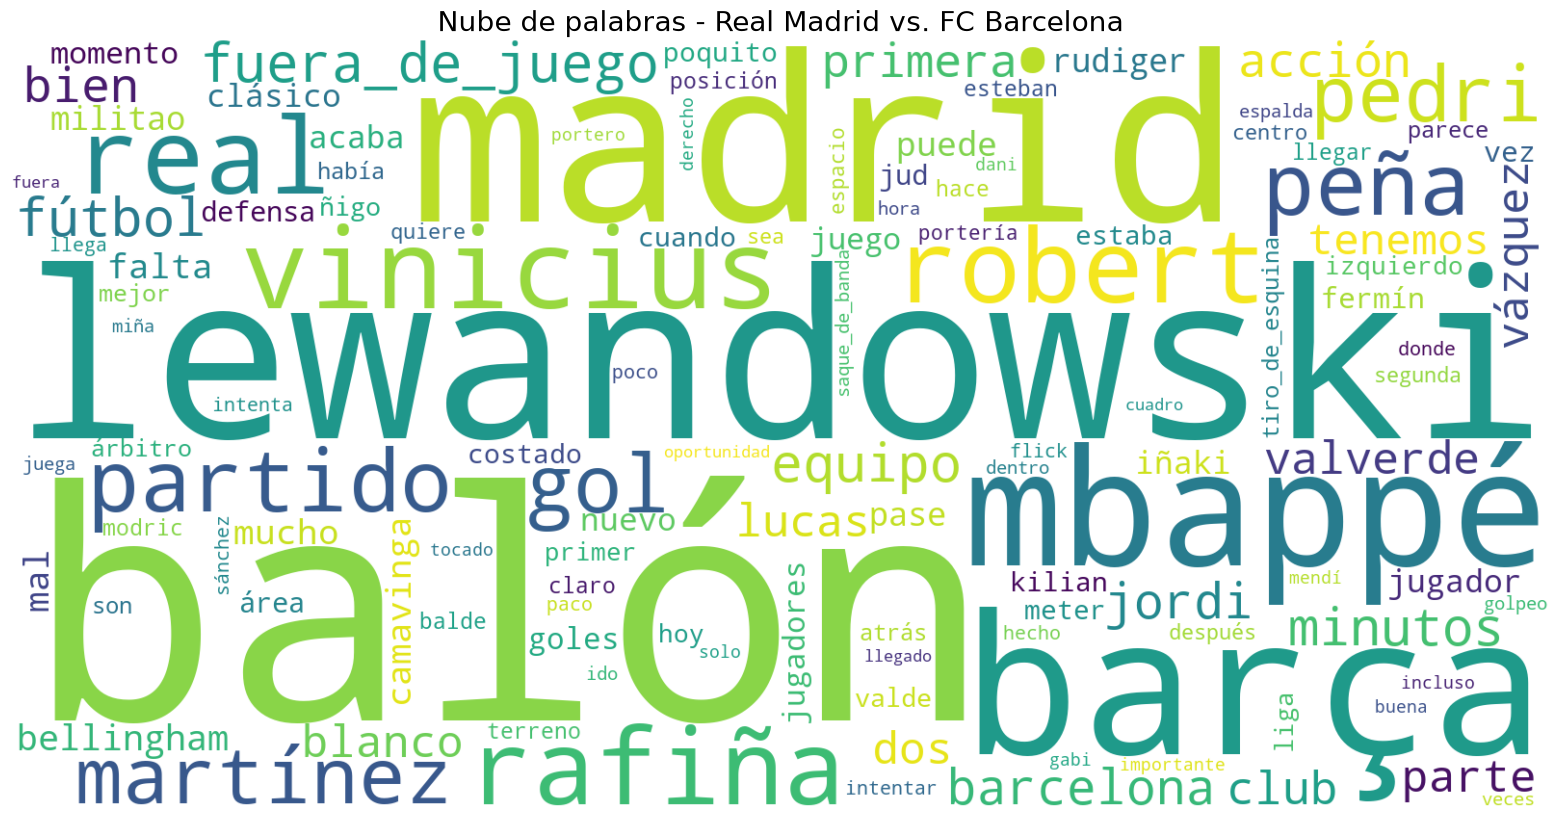

In [76]:
nube = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='viridis',
    max_words=120,
    prefer_horizontal=0.95,
).generate_from_frequencies(frecuencias)

plt.figure(figsize=(16, 8))
plt.imshow(nube, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - ' + PARTIDO['equipos'], fontsize=20)
plt.tight_layout(pad=0)
plt.savefig(BASE_DIR / 'nube_palabras.png', dpi=200, bbox_inches='tight')
plt.show()

In [77]:
%%writefile "{BASE_DIR}/preprocesamiento.py"
import re
import unicodedata

TERMINOS_PROTEGIDOS = {
    r'saque de esquina|tiro de esquina|c[oó]rner': 'tiro_de_esquina',
    r'saque de banda': 'saque_de_banda',
    r'tarjeta amarilla|cartulina amarilla': 'tarjeta_amarilla',
    r'tarjeta roja|cartulina roja': 'tarjeta_roja',
    r'fuera de juego(?:s)?|fuera de lugar': 'fuera_de_juego',
    r'bal[oó]n parado': 'balon_parado',
}

PALABRAS_VACIAS = {
    'a', 'al', 'ante', 'bajo', 'con', 'contra', 'de', 'del', 'desde', 'durante', 'en', 'entre',
    'hacia', 'hasta', 'mediante', 'para', 'por', 'según', 'sin', 'sobre', 'tras',
    'el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas', 'lo',
    'y', 'o', 'u', 'e', 'ni', 'que', 'pero', 'aunque', 'porque', 'si', 'como',
    'yo', 'tu', 'tú', 'él', 'ella', 'ello', 'nosotros', 'vosotros', 'ellos', 'ellas',
    'me', 'te', 'se', 'le', 'les', 'su', 'sus', 'mi', 'mis',
    'esto', 'eso', 'esa', 'ese', 'esta', 'este', 'esas', 'esos', 'estas', 'estos', 'aquello',
    'es', 'ha', 'han', 'va', 'hay', 'está', 'están', 'era', 'fue', 'ser', 'estar',
    'tiene', 'tienen', 'soy', 'somos', 'sido',
    'no', 'sí', 'más', 'muy', 'ya', 'también', 'ahora', 'ahí', 'aquí', 'así',
    'cómo', 'qué', 'cuál', 'cuándo', 'dónde', 'quién',
    'todo', 'toda', 'todos', 'todas', 'otra', 'otro', 'otros', 'otras',
    'cada', 'algo', 'alguna', 'alguno', 'algunos', 'algunas', 'mismo', 'misma',
}

MULETILLAS = {
    'eh', 'ehh', 'bueno', 'vamos', 'ver', 'vemos', 'mira', 'miren', 'oye',
    'digamos', 'verdad', 'evidentemente', 'prácticamente', 'sabemos',
    'creo', 'fíjate', 'ojo', 'decir', 'pues',
}

TOKEN_RE = re.compile(r"[a-záéíóúñüç]+(?:_[a-záéíóúñüç]+)*")


def normalizar_texto(texto):
    texto = unicodedata.normalize('NFC', str(texto)).lower()
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def proteger_terminos(texto, terminos=TERMINOS_PROTEGIDOS):
    for patron, token in terminos.items():
        texto = re.sub(patron, token, texto, flags=re.IGNORECASE)
    return texto


def tokenizar(texto):
    return TOKEN_RE.findall(texto)


def quitar_vacias(tokens, vacias=PALABRAS_VACIAS | MULETILLAS):
    return [t for t in tokens if t not in vacias and len(t) > 1]


def preprocesar_texto(texto):
    texto = normalizar_texto(texto)
    texto = proteger_terminos(texto)
    tokens = tokenizar(texto)
    return quitar_vacias(tokens)

Overwriting /workspace/preprocesamiento.py


In [78]:
import importlib

import preprocesamiento
importlib.reload(preprocesamiento)

vocabulario = {
    'terminos_protegidos': preprocesamiento.TERMINOS_PROTEGIDOS,
    'palabras_vacias': sorted(preprocesamiento.PALABRAS_VACIAS),
    'muletillas': sorted(preprocesamiento.MULETILLAS),
}
(BASE_DIR / 'vocabulario_preprocesamiento.json').write_text(
    json.dumps(vocabulario, ensure_ascii=False, indent=2), encoding='utf-8'
)

2062

### Conclusiones de esta Fase 

Al aplicar las funciones de tranformación, el corpus del partido se redujo en un 50% de tokens luego de quitar palabras vacias y muletillas que se utilizan dentro de la narración. El desarrollo de la función de procesamiento de texto no fue complicada, unicamente se tuvo una complicación o dificultad en poder mantener las palabras o frases más complejas previo a tokenizar.

Por medio de la nube de palabras podemos validar que la mayoría de palabras que se ven son nombres y apellidos de jugadores. 

## Extracción de eventos, estadísticas y evaluación

### Diccionario de eventos, sinónimos y reglas de exclusión

Para obtener las estadísticas, defino un diccionario de los distintos eventos que nos interesa obtener. Además, es necesario añadir ciertas reglas de exclusión debido a que en ocasiones ciertas palabras pueden aparecer en distintos eventos.

In [79]:
EVENTOS_PATRONES = {
  'Goles': {
    'incluir': r'¡\s*gol|golazo|\bgol\b\s*[.,!]|gol de [a-zñáéíóú]+|gol del [a-zñáéíóú]+',
    'excluir': r'casi gol|estuvo cerca del gol|pudo (?:ser|marcar) el gol|gol anulado|no (?:fue|es) gol|se (?:le )?escap[oó] el gol|gran ocasi[oó]n de gol|gol anulado|anulado por fuera de juego'
  },
  'Tiros de esquina': {
    'incluir': r'saque de esquina|tiro de esquina|c[oó]rner',
    'excluir': None
  },
  'Saques de banda': {
    'incluir': r'saque de banda|\blateral\b',
    'excluir': r'lateral (?:izquierdo|derecho)|centro lateral|posici[oó]n de lateral|defensivo|desde lateral'
  },
  'Tiros o remates': {
    'incluir': r'\bremat(?:a|e|an|ando)\b|\bdispar(?:a|o|an|ando)\b|\bchut(?:a|e|an|ando)\b|tiro a (?:puerta|gol|marco)|cabezazo|volea|punta',
    'excluir': r'tiro de esquina|tiro libre'
  },
  'Faltas': {
    'incluir': r'\bfalta(?:s)?\b|infracci[oó]n|le hace penalti',
    'excluir': r'sin falta|no hay falta'
  },
  'Tarjetas amarillas': {
    'incluir': r'tarjeta amarilla|cartulina amarilla|amonestad',
    'excluir': None
  },
  'Tarjetas rojas': {
    'incluir': r'tarjeta roja|cartulina roja|\bexpulsad\w*\b',
    'excluir': r'puedes? acabar|podr[ií]a.*expuls|te expulse'
  },
  'Fuera de juego': {
    'incluir': r'fuera de juego|fuera de lugar|posici[oó]n adelantada|offside',
    'excluir': r'no (?:hay|hab[ií]a|fue) fuera de juego|no est(?:aba|á) (?:en )?fuera de juego'
  }
}

### Función de conteo

Con la función `evaluar_linea` marcamos una línea dentro de nuestra naracción como parte de un evento del anterior diccionario.

In [80]:
def evaluar_linea(texto, patrones):
  texto = str(texto)
  if patrones.get('excluir') and re.search(patrones['excluir'], texto, flags = re.IGNORECASE):
    return False
  return bool(re.search(patrones['incluir'], texto, flags = re.IGNORECASE))

def contar_eventos(tabla, eventos = EVENTOS_PATRONES, columna_texto = 'texto_original'):
  conteos = {}
  detalle = {}

  for evento, patrones in eventos.items():
    mask = tabla[columna_texto].apply(lambda t: evaluar_linea(t, patrones))
    conteos[evento] = int(mask.sum())
    detalle[evento] = tabla.loc[mask, ['linea', 'tiempo_hms', 'segundos', columna_texto]].reset_index(drop=True)
  return conteos, detalle

conteos_brutos, lineas_detectadas_brutas = contar_eventos(partido_df)
conteos_brutos

{'Goles': 31,
 'Tiros de esquina': 18,
 'Saques de banda': 12,
 'Tiros o remates': 21,
 'Faltas': 32,
 'Tarjetas amarillas': 7,
 'Tarjetas rojas': 0,
 'Fuera de juego': 36}

Verificando los resultados vs los valores reales que podemos encontrar, vemos que marcamos 31 goles. Esto es debido a que en ocasiones se repite muchas veces la palabras dentro de nuestro diccicionario de eventos para gol cuando se marca un gol. Parte del festejo que se realiza y para dar más emoción a la naracción, por lo que es necesario hacer una limpieza de estos eventos duplicados

In [81]:
def deduplicar_por_tiempo(tabla_detectada, ventana_segundos = 60):
  if tabla_detectada.empty:
    return tabla_detectada

  tabla = tabla_detectada.sort_values("segundos").reset_index(drop = True)
  grupos, grupo_actual = [], [0]
  for i in range(1, len(tabla)):
    if tabla.loc[i, 'segundos'] - tabla.loc[grupo_actual[-1], 'segundos'] <= ventana_segundos:
      grupo_actual.append(i)
    else:
      grupos.append(grupo_actual)
      grupo_actual = [i]

  grupos.append(grupo_actual)

  return pd.DataFrame([tabla.loc[g[0]] for g in grupos]).reset_index(drop=True)

# Ventana de segundos
VENTANA_DEDUP = {
  'Goles': 60,
  'Tiros de esquina': 20,
  'Saques de banda': 60,
  'Fuera de juego': 60,
  'Tiros o remates': None,
  'Faltas': None,
  'Tarjetas amarillas': None,
  'Tarjetas rojas': None,
}

conteos_estimados = {}
lineas_detectadas = {}
for evento, tabla in lineas_detectadas_brutas.items():
  ventana = VENTANA_DEDUP.get(evento)
  tabla_final = deduplicar_por_tiempo(tabla, ventana) if ventana else tabla
  conteos_estimados[evento] = len(tabla_final)
  lineas_detectadas[evento] = tabla_final

pd.DataFrame({'bruto_por_linea': conteos_brutos, 'estimacion_final': conteos_estimados})

,bruto_por_linea,estimacion_final
Goles,31,13
Tiros de esquina,18,13
Saques de banda,12,11
Tiros o remates,21,21
Faltas,32,32
Tarjetas amarillas,7,7
Tarjetas rojas,0,0
Fuera de juego,36,17


De igual manera observamos un incremento muy grande en los goles obtenidos, por lo que podemos validar directamente qué eventos se están marcando como gol mediante una función auxiliar para validar qué otros patrones podemos añadir en las exclusiones

In [82]:
pd.set_option('display.max_colwidth', None)

def exportar_muestra_revision(evento, lineas_a_analizar = lineas_detectadas):
  tabla_evento = lineas_a_analizar.get(evento)

  if tabla_evento is None or tabla_evento.empty:
    print(f'No hay lineas detectadas para "{evento}".')
    return tabla_evento

  return tabla_evento.sort_values('linea')

exportar_muestra_revision('Goles')

,linea,tiempo_hms,segundos,texto_original
0,117,00:14:19,859,Mbappé no ha encontrado el camino del gol. Segunda oportunidad para el equipo blanco con ese despeje a la remanguillé
1,134,00:16:33,993,"Cómo ha levantado el brazo Iñaki Peña y otra vez al filo del gol, pero estaba en fuera de juego Kilian Mbappé por muy poquito, pero estaba en fuera de juego."
2,197,00:24:34,1474,"Mbappé, claro, es gol."
3,260,00:32:11,1931,"Qué bueno, qué bueno, qué bueno, qué bueno. Gol."
4,488,00:59:34,3574,"sé. Rober Lewandowski, qué bueno, qué bueno, qué bueno. ¡Gol!"
5,506,01:01:51,3711,"Ahora es Balde. Balde por el costado izquierdo, obligado a reaccionar el Real Madrid, pero Roberovskiquez. ¡Gol! ¡Gol!"
6,570,01:10:11,4211,"el gol, pero cómo le encimado, cómo se ha hecho enorme. Desmarque ruptura no había fuera de juego. Qué bien lo hace Killan Mbappé, pero sobre todo en el timing ya estaba ahí Ñaki Peña."
7,598,01:13:37,4417,"los jugadores más rápidos con balón, con Vinicius, etcétera, esperar, si a veces esperar un poquito que acerca al al gol."
8,621,01:16:23,4583,"Si el Madrid mete un gol, el Barça va a sufrir de Olindo. Modric para filtrar."
9,676,01:23:19,4999,"Gol de crack, gol de tremendo futbolista. La viña mal a lo grande. ¡Qué gol!"


Observamos que el narrador menciona muchas veces la palabra gol de manera hipotetica o mencionando que el gol estuvo cerca. Por lo que podríamos añadir más patrones para excluir estas narraciones o directamente excluir aquellas que no aplican o identificamos manualmente como suposiciones o hipoteticos del narrador.

In [83]:
LINEAS_EXCLUIDAS_MANUALMENTE = {
  'Goles': {117, 134, 570, 598, 621, 746, 790},
  'Fuera de juego': set(),
  'Tiros de esquina': set(),
  'Saques de banda': set(),
  'Tiros o remates': set(),
  'Faltas': set(),
  'Tarjetas amarillas': set(),
  'Tarjetas rojas': set(),
}

conteos_ajustados = {}
lineas_detectadas_ajustadas = {}
for evento, tabla in lineas_detectadas.items():
  excluir = LINEAS_EXCLUIDAS_MANUALMENTE.get(evento, set())
  tabla_ajustada = tabla[~tabla['linea'].isin(excluir)].reset_index(drop=True)
  lineas_detectadas_ajustadas[evento] = tabla_ajustada
  conteos_ajustados[evento] = len(tabla_ajustada)

pd.DataFrame({'tras_dedup': conteos_estimados, 'tras_revision_manual': conteos_ajustados})

,tras_dedup,tras_revision_manual
Goles,13,6
Tiros de esquina,13,13
Saques de banda,11,11
Tiros o remates,21,21
Faltas,32,32
Tarjetas amarillas,7,7
Tarjetas rojas,0,0
Fuera de juego,17,17


In [84]:
exportar_muestra_revision('Goles', lineas_detectadas_ajustadas)

,linea,tiempo_hms,segundos,texto_original
0,197,00:24:34,1474,"Mbappé, claro, es gol."
1,260,00:32:11,1931,"Qué bueno, qué bueno, qué bueno, qué bueno. Gol."
2,488,00:59:34,3574,"sé. Rober Lewandowski, qué bueno, qué bueno, qué bueno. ¡Gol!"
3,506,01:01:51,3711,"Ahora es Balde. Balde por el costado izquierdo, obligado a reaccionar el Real Madrid, pero Roberovskiquez. ¡Gol! ¡Gol!"
4,676,01:23:19,4999,"Gol de crack, gol de tremendo futbolista. La viña mal a lo grande. ¡Qué gol!"
5,732,01:30:12,5412,"Rafiña que va a correr, Rafiña que pica el balón, puede caer otro. La salelina, gol,"


Con esto bien podríamos seguir filtrando ciertos resultados. Pero realmente estaríamos ya analizando línea por línea y analizando vs el verdadero resultado del partido. Lo que podría inflar nuestros resultados de goles. Dentro de los casos que se encuentran en esta lista, existen algunos goles que fueron anulados, lo cuál nuestro notebook no puede detectar actualmente con la naracción que tenemos.

### Separación por equipos

Sabiendo los miembros de cada equipo, o patrones que identifican a cada equipo, podemos separar cada evento dependiendo de qué otras palabras se encuentren cerca de la naracción. Si en una misma línea aparece el nombre de un jugador, o del mismo equipo, se le atribute a este equipo.

In [85]:
JUGADORES_LOCAL = {
  'real madrid', 'mbappe', 'mbappé', 'vinicius', 'vinícius', 'bellingham', 'valverde',
  'rudiger', 'rüdiger', 'camavinga', 'tchouameni', 'tchouaméni', 'militao', 'militão',
  'mendy', 'mendí', 'vazquez', 'vázquez', 'lunin', 'luning', 'endrick', 'ceballos',
  'modric', 'modrić', 'brahim', 'fran garcia', 'garcía', 'ancelotti',
}

JUGADORES_VISITANTE = {
  'barcelona', 'barça', 'barca', 'blaugrana', 'lewandowski', 'yamal', 'raphinha', 'rafiña',
  'pedri', 'gavi', 'kounde', 'koundé', 'kundé', 'cubarsi', 'cubarsí', 'kubarsí', 'balde',
  'valde', 'peña', 'pena', 'casado', 'casadó', 'marcasadó', 'fermin', 'fermín', 'de jong',
  'olmo', 'iñigo martinez', 'iñigo martínez', 'flick',
}


def inferir_equipo(texto):
  texto_l = str(texto).lower()
  en_local = any(nombre in texto_l for nombre in JUGADORES_LOCAL)
  en_visitante = any(nombre in texto_l for nombre in JUGADORES_VISITANTE)
  if en_local and not en_visitante:
    return 'Real Madrid'
  if en_visitante and not en_local:
    return 'Barcelona'
  if en_local and en_visitante:
    return 'Ambos/ambiguo'
  return 'Sin determinar'


resumen_por_equipo = {}
for evento, tabla_evento in lineas_detectadas_ajustadas.items():
  if tabla_evento.empty:
    resumen_por_equipo[evento] = {}
    continue
  equipos = tabla_evento['texto_original'].apply(inferir_equipo)
  resumen_por_equipo[evento] = equipos.value_counts().to_dict()

pd.DataFrame(resumen_por_equipo).fillna(0).astype(int).T

,Sin determinar,Barcelona,Real Madrid,Ambos/ambiguo
Goles,2,2,1,1
Tiros de esquina,4,0,7,2
Saques de banda,2,0,3,6
Tiros o remates,5,7,2,7
Faltas,7,4,5,16
Tarjetas amarillas,2,0,4,1
Tarjetas rojas,0,0,0,0
Fuera de juego,2,4,8,3


Por equipo, estas son las estadísticas oficiales que podemos obtener:

| Stat | Real Madrid | Barcelona |
| ---- | ----------- | --------- |
| Goles | 0 | 4 |
| Tiros de esquina | 10 | 3 |
| Tiros o remates | 9 | 15 |
| Faltas | 15 | 17 |
| Tarjetas amarillas | 2 | 5 |
| Tarjetas rojas | 0 | 0 |
| Fuera de juego | 12 | 1 |

Obtenemos las estadísticas oficionales de internet de este partido específico.

In [86]:
ESTADISTICAS_OFICIALES = {
  'Goles': 4,
  'Tiros de esquina': 13,
  'Saques de banda': None,
  'Tiros o remates': 24,
  'Faltas': 32,
  'Tarjetas amarillas': 7,
  'Tarjetas rojas': 0,
  'Fuera de juego': 13,
}

estadisticas_oficiales_df = pd.DataFrame(
  [{'Estadistica': k, 'Valor_oficial': v} for k, v in ESTADISTICAS_OFICIALES.items()]
)
estadisticas_oficiales_df

,Estadistica,Valor_oficial
0,Goles,4.0
1,Tiros de esquina,13.0
2,Saques de banda,NaN
3,Tiros o remates,24.0
4,Faltas,32.0
5,Tarjetas amarillas,7.0
6,Tarjetas rojas,0.0
7,Fuera de juego,13.0


In [87]:
def construir_tabla_comparativa(estimados, oficiales):
  filas = []
  for evento, estimado in estimados.items():
    oficial = oficiales.get(evento)
    if oficial is None:
      filas.append({
        'Estadistica': evento,
        'Estimacion': estimado,
        'Valor_oficial': 'No disponible',
        'Diferencia_absoluta': None,
        'Porcentaje_acierto': None,
      })
      continue
    
    diferencia = abs(estimado - oficial)
    if oficial == 0:
      porcentaje = 100.0 if estimado == 0 else 0.0
    else:
      porcentaje = max(0.0, 100 - (diferencia / oficial * 100))
    filas.append({
      'Estadistica': evento,
      'Estimacion': estimado,
      'Valor_oficial': oficial,
      'Diferencia_absoluta': diferencia,
      'Porcentaje_acierto': round(porcentaje, 1),
    })
  return pd.DataFrame(filas)


tabla_resultados = construir_tabla_comparativa(conteos_ajustados, ESTADISTICAS_OFICIALES)
tabla_resultados

,Estadistica,Estimacion,Valor_oficial,Diferencia_absoluta,Porcentaje_acierto
0,Goles,6,4,2.0,50.0
1,Tiros de esquina,13,13,0.0,100.0
2,Saques de banda,11,No disponible,NaN,NaN
3,Tiros o remates,21,24,3.0,87.5
4,Faltas,32,32,0.0,100.0
5,Tarjetas amarillas,7,7,0.0,100.0
6,Tarjetas rojas,0,0,0.0,100.0
7,Fuera de juego,17,13,4.0,69.2


### Conclusiones de esta fase

El método que estamos utilizando para la detección de distintos eventos durante el partido alcanzó un 86.7% de acierto promedio sobre las seis estadísticas con valor oficial disponible (excluyendo saques de banda), con un 100% de acierto exacto en Faltas, Tarjetas amarillas y Tarjetas rojas. El comentarista de este partido anuncia estos tres eventos con un vocabulario bastante estable, o haciendo uso de las mismas expresiones, lo que hace sencilla su detección mediante patrones regex.

Para las demás estadísticas fue necesario aplicar modificaciones adicionales sobre la extracción:

Para los **Tiros de esquina**, sin ventana de deduplicación obteníamos un resultado mayor al real. Con una ventana de 20 segundos logramos coincidir exactamente con el valor oficial. Hay que tomar en cuenta que mover esta ventana cambia el resultado: con 60 segundos obtenemos menos tiros de esquina de los reales, porque en un partido pueden ocurrir varios tiros de esquina distintos en un periodo de tiempo corto y una ventana muy ancha termina fusionando eventos que son independientes.

**Goles** sigue siendo nuestra estadística con menor porcentaje de acierto (50% de acierto), pero el resultado final es mucho mejor de lo que sufiere el conteo bruto por línea (31 antes de deduplicar y filtrar). Revisando las 6 líneas que quedan tras el filtro, identificamos que los 2 eventos extra que detectamos corresponden al mismo gol anulado de Mbappé, mencionado dos veces con casi 8 minutos de diferencia mientras se revisaba el fuera de juego.

El **Fuera de juego** también quedo sobreestimado (69.2% de acierto), aunque igualmente mejoró frente al conteo bruto por línea. La causa es la misma que con los goles, el narrador retoma el mismo fuera de juego en distintas ocasiones.

**Tiros o remates** quedó en 19 vs 24 oficiales (79.2% de acierto).

Sobre los **Saques de banda**, no existe una estadística oficial que hayamos podido encontrar, por lo que no es posible obtener el porcentaje de acierto. Comparado con lo que se espera de un partido de fútbol regular, nuestro valor (11) parece bajo; sin embargo, al no contar con un dato oficial no podemos afirmar si esto refleja un problema del método o simplemente cómo se narró este partido en particular.

Sobre la **separación por equipo**, las proporciones entre eventos atribuidos a cada equipo son razonables, pero la atribución individual es débil. En conjunto, el 56% de los eventos detectados quedó como "Sin determinar" o "Ambos/Ambiguo" en vez de asigarse al equipo correcto. Esto occure principalmente porque en una misma línea suelen mencionarse jugadores de ambos equipos, y porque la transcripción automática distorciona varios nombres de jugadores hasta el punto que no coinciden con ninguna palabra de nuestras listas.

La metodología que utilizamos tiene una limitación, se basa únicamente en análisis léxico línea por línea, con reglas de exclusión específicas y una heurística de deduplicación temporal por ventanas. No entiende el contexto narrativo completo, y su precisión depende en gran medida de qué tan bien esta nuestro diccionario de inclusiones/exclusiones. Aun con esta limitación, siete de las ocho estadísticas objetivo terminaron con una diferencia absoluta de 4 o menos frente al valor oficial, lo cual es razonable para un método basado en reglas.